# Plotting notebook
For testing different plots

## Data Imports


In [1]:
import plot_OM as plom
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import xarray as xr
import pandas as pd

import regionmask

In [2]:
default_BB = plom.Kuroshio_BB
proj_choices = plom.PROJECTION_CHOICES(default_BB)
proj = proj_choices['pc']
mid_lon = proj.proj4_params['lon_0']

In [8]:
mid_lon

147.0

### download data

In [ ]:
#ds = plom.fetch_ARGO_data(default_BB, start_date='2025-01-01', end_date='2026-01-01')
#ds.to_zarr('./data/Kuroshio_2025')

## Plotting


In [3]:
ds = xr.open_zarr('./data/Kuroshio_2025')

### plotting different time windows

going to plot first 7, 14, 30 days of may 

In [4]:
## time ranges
window_7d = (
    pd.Timestamp('2025-05-01'), pd.Timestamp('2025-05-08')
)
window_14d = (
    pd.Timestamp('2025-05-01'), pd.Timestamp('2025-05-15')
)
window_21d = (
    pd.Timestamp('2025-05-01'), pd.Timestamp('2025-05-22')
)
window_28d = (
    pd.Timestamp('2025-05-01'), pd.Timestamp('2025-05-29')
)
window_1m = (
    pd.Timestamp('2025-05-01'), pd.Timestamp('2025-06-01')
)

windows = [
    window_7d,
    window_14d,
    window_21d,
    #window_28d,
    window_1m
]

def select_timerange(ds, window):
    daily = ds.TIME.dt.round('1d').compute()
    mask = (daily >= window[0]) & (daily < window[1])

    new_ds = ds.copy()

    return new_ds.where(mask, drop=True)

In [5]:
def plot_obj_map(ds, ax, threshold=0.8, projection=proj, cmap=mpl.colormaps['viridis'], **calc_kwargs):

    mp, ergrid, xg, yg = plom.calculate_objective_map(ds, **calc_kwargs)

    land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
    mask_land = land.mask(xg, yg)

    mask = ergrid > threshold

    masked_mp = mp.copy()   
    masked_mp[mask] = np.nan

    plot_mp = np.where(np.isnan(mask_land), masked_mp.T, np.nan)

    Tmin = 0 # np.nanmin(plot_mp)
    Tmax = 32 # np.nanmax(plot_mp)
    levels = np.linspace(Tmin, Tmax, 17)
    norm = mpl.colors.Normalize(vmin=Tmin, vmax=Tmax, clip=True)


    im = ax.contourf(xg - mid_lon, yg, plot_mp, transform=projection, cmap=cmap, levels=levels, norm=norm)
    #plom.format_geoaxes(ax)

    return im

#### actually plottin n shit

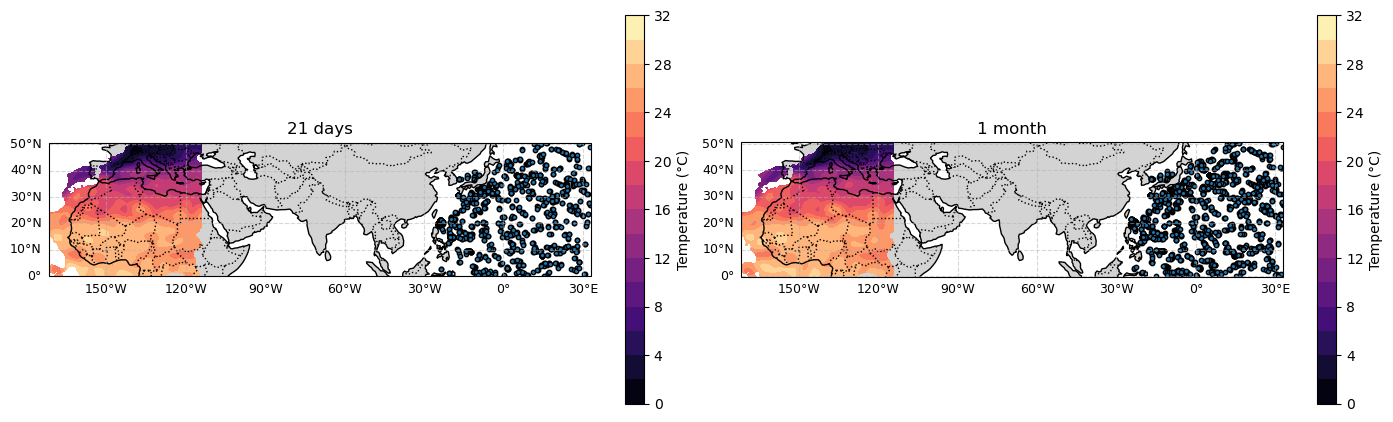

In [9]:
titles = [
    '7 days', '14 days',
    '21 days', '1 month'
]

plot_proj = ccrs.PlateCarree()
cmap = mpl.colormaps['magma']

fig, axs = plt.subplots(1, 2, figsize=(14, 10), subplot_kw={'projection': plot_proj})
axs = axs.flatten()
fig.tight_layout(h_pad=10)   

for axid, ax in enumerate(axs):

    axid += 2

    plot_ds = select_timerange(ds, windows[axid])
    
    im = plot_obj_map(plot_ds, ax, projection=plot_proj, cmap=cmap, threshold=0.3, xcor_km=450, ycor_km=450)
    ax.scatter(
        plot_ds.LONGITUDE, plot_ds.LATITUDE,
        transform = plot_proj,
        s = 10, edgecolor='black'
    )
    plom.format_geoaxes(ax, crs=proj)

    ax.set_title(f'{titles[axid]}')

    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation='vertical',
        shrink=0.4
    )
    cbar.set_label('Temperature (°C)')

plt.show()

In [ ]:
titles = [
    '7 days', '14 days',
    '21 days', '1 month'
]

plot_proj = ccrs.PlateCarree(central_longitude=mid_lon)
cmap = mpl.colormaps['magma']

fig, axs = plt.subplots(1, 3, figsize=(14, 8), subplot_kw={'projection': proj})
axs = axs.flatten()
fig.tight_layout(h_pad=10)   

for axid, ax in enumerate(axs):

    axid += 1

    plot_ds = select_timerange(ds, windows[axid])
    
    im = plot_obj_map(plot_ds, ax, projection=plot_proj, cmap=cmap, threshold=0.3, xcor_km=350, ycor_km=350)
    ax.scatter(
        plot_ds.LONGITUDE - mid_lon, plot_ds.LATITUDE,
        transform = plot_proj,
        s = 10, edgecolor='black'
    )
    plom.format_geoaxes(ax, crs=proj)

    ax.set_title(f'{titles[axid]}')

    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation='vertical',
        shrink=0.4
    )

cbar.set_label('Temperature (°C)')

plt.show()

In [ ]:
titles = [
    '21 days', '1 month'
]

dc_scales = [
    400, 425, 450
]

plot_proj = ccrs.PlateCarree(central_longitude=mid_lon)
cmap = mpl.colormaps['magma']

fig, axs = plt.subplots(1, 3, figsize=(14, 8), subplot_kw={'projection': proj})
axs = axs.flatten()
fig.tight_layout(h_pad=10)   

for axid, ax in enumerate(axs):

    plot_ds = select_timerange(ds, window_21d)

    dcs = dc_scales[axid]
    
    im = plot_obj_map(plot_ds, ax, projection=plot_proj, cmap=cmap, threshold=0.3, nx=100, xcor_km=dcs, ycor_km=dcs)
    ax.scatter(
        plot_ds.LONGITUDE - mid_lon, plot_ds.LATITUDE,
        transform = plot_proj,
        s = 10, edgecolor='black'
    )
    plom.format_geoaxes(ax, crs=proj)

    ax.set_title(f'{dc_scales[axid]}km')
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation='vertical',
        shrink=0.4
    )

cbar.set_label('Temperature (°C)')
plt.show()

## end sec

In [ ]:
titles = [
    'January', 'April', 'July', 'October'
]

seasonal_windows = [
    (pd.Timestamp(f'2025-{3*i+1:02d}-01'), pd.Timestamp(f'2025-{3*i+1:02d}-22')) for i in range(4)
]

dcs = 450

plot_proj = ccrs.PlateCarree(central_longitude=mid_lon)
cmap = mpl.colormaps['magma']

fig, axs = plt.subplots(1, 2, figsize=(14, 10), subplot_kw={'projection': proj})
axs = axs.flatten()
fig.tight_layout(h_pad=10)   

for axid, ax in enumerate(axs):

    axid += 2

    window = seasonal_windows[axid]

    plot_ds = select_timerange(ds, window)
    
    im = plot_obj_map(plot_ds, ax, projection=plot_proj, cmap=cmap, threshold=0.3, nx=100, xcor_km=dcs, ycor_km=dcs)
    ax.scatter(
        plot_ds.LONGITUDE - mid_lon, plot_ds.LATITUDE,
        transform = plot_proj,
        s = 10, edgecolor='black'
    )
    plom.format_geoaxes(ax, crs=proj)

    ax.set_title(f'{titles[axid]}')
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation='vertical',
        shrink=0.4
    )
    cbar.set_label('Temperature (°C)')

plt.show()

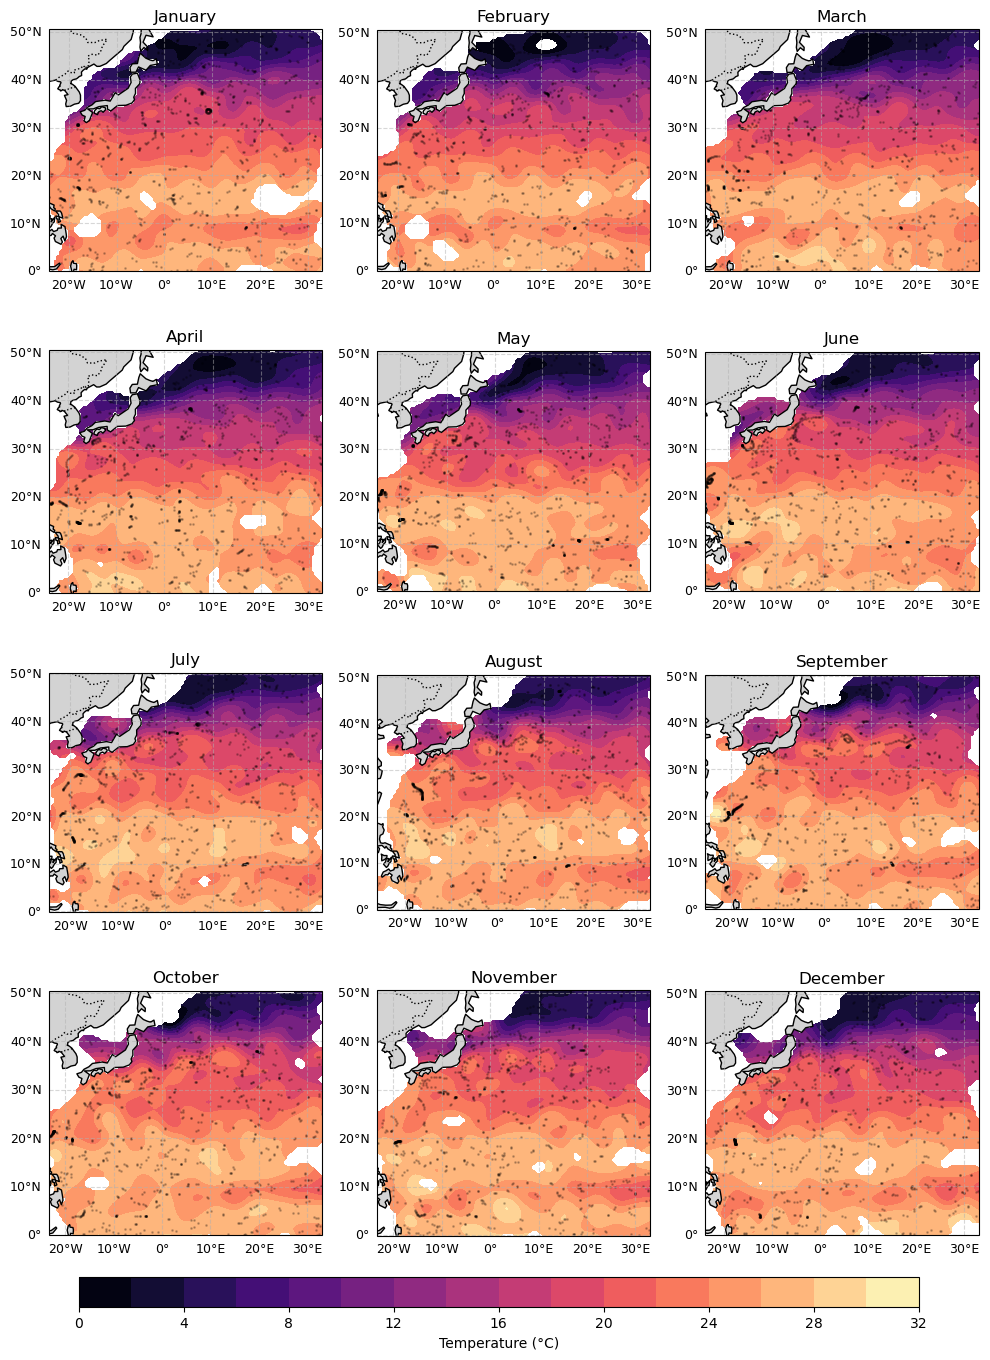

In [8]:
titles = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

seasonal_windows = [
    (pd.Timestamp(f'2025-{i+1:02d}-01'), pd.Timestamp(f'2025-{i+1:02d}-22')) for i in range(12)
]

dcs = 450

plot_proj = ccrs.PlateCarree(central_longitude=mid_lon)
cmap = mpl.colormaps['magma']

fig, axs = plt.subplots(4, 3, figsize=(12, 15), subplot_kw={'projection': proj})
axs = axs.flatten()
#fig.tight_layout(h_pad=10)   

for axid, ax in enumerate(axs):

    window = seasonal_windows[axid]

    plot_ds = select_timerange(ds, window)
    
    im = plot_obj_map(plot_ds, ax, projection=plot_proj, cmap=cmap, threshold=0.3, nx=100, xcor_km=dcs, ycor_km=dcs)
    ax.scatter(
        plot_ds.LONGITUDE - mid_lon, plot_ds.LATITUDE,
        transform = plot_proj,
        s = 1, color='black', alpha=0.2
    )
    plom.format_geoaxes(ax, crs=proj)

    ax.set_title(f'{titles[axid]}')

fig.subplots_adjust(bottom=0.06)
cbar_ax = fig.add_axes(rect=(0.15, 0.02, 0.7, 0.02))
cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation='horizontal'
)

cbar.set_label('Temperature (°C)')

plt.show()